In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import wbgapi as wb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

print("Setup complete.")

Setup complete.


In [2]:
# ── Bank Tickers & Universe ────────────────────────────────────────────────────
BANKS = {
    "GARAN": "Garanti BBVA",
    "AKBNK": "Akbank",
    "ISCTR": "İş Bankası",
    "YKBNK": "Yapı Kredi",
    "HALKB": "Halkbank",
    "VAKBN": "Vakıfbank",
}

TICKERS_YAHOO = [f"{t}.IS" for t in BANKS.keys()]

# ── Date Range ─────────────────────────────────────────────────────────────────
START_DATE = "2020-01-01"
END_DATE   = "2026-05-01"

print(f"Coverage: {START_DATE} to {END_DATE}")
print(f"Banks: {list(BANKS.values())}")

Coverage: 2020-01-01 to 2026-05-01
Banks: ['Garanti BBVA', 'Akbank', 'İş Bankası', 'Yapı Kredi', 'Halkbank', 'Vakıfbank']


In [3]:
# ── USDTRY & EURTRY FX Data ────────────────────────────────────────────────────
print("Downloading FX data...")

fx = yf.download(["USDTRY=X", "EURTRY=X"], 
                  start=START_DATE, 
                  end=END_DATE, 
                  auto_adjust=True)["Close"]

fx.columns = ["EURTRY", "USDTRY"]
fx = fx.dropna()

print(f"FX data shape: {fx.shape}")
print(f"Date range: {fx.index[0].date()} to {fx.index[-1].date()}")
fx.tail()

[*********************100%***********************]  2 of 2 completed

FX data shape: (1647, 2)
Date range: 2020-01-01 to 2026-04-30


,EURTRY,USDTRY
Date,,
2026-04-24,52.46,44.98
2026-04-27,52.67,45.01
2026-04-28,52.79,45.03
2026-04-29,52.92,45.06
2026-04-30,52.78,45.17


In [4]:
# ── Bank Stock Prices ──────────────────────────────────────────────────────────
print("Downloading bank stock prices...")

stocks = yf.download(TICKERS_YAHOO,
                     start=START_DATE,
                     end=END_DATE,
                     auto_adjust=True)["Close"]

stocks.columns = [col.replace(".IS", "") for col in stocks.columns]
stocks = stocks.dropna()

print(f"Stock data shape: {stocks.shape}")
print(f"Date range: {stocks.index[0].date()} to {stocks.index[-1].date()}")
stocks.tail()

[*********************100%***********************]  6 of 6 completed

Stock data shape: (1585, 6)
Date range: 2020-01-02 to 2026-04-30


,AKBNK,GARAN,HALKB,ISCTR,VAKBN,YKBNK
Date,,,,,,
2026-04-24,77.90,138.00,40.82,14.45,33.48,37.64
2026-04-27,77.70,136.70,39.86,14.31,32.92,37.60
2026-04-28,75.95,134.60,38.30,13.98,32.24,37.06
2026-04-29,73.70,132.70,37.50,14.02,31.34,36.56
2026-04-30,73.20,133.80,37.84,14.34,31.66,37.04


In [5]:
# ── World Bank Macro Data ──────────────────────────────────────────────────────
print("Downloading World Bank macro data...")

indicators = {
    "FP.CPI.TOTL.ZG":   "inflation_pct",
    "NY.GDP.MKTP.KD.ZG": "gdp_growth_pct",
    "BN.CAB.XOKA.GD.ZS": "current_account_gdp",
    "GC.DOD.TOTL.GD.ZS": "govt_debt_gdp",
}

macro_frames = []
for code, label in indicators.items():
    try:
        data = wb.data.DataFrame(code, "TUR", mrv=10).T
        data.index = pd.to_datetime(data.index, format="YR%Y")
        data.columns = [label]
        macro_frames.append(data)
        print(f"  {label}: OK")
    except Exception as e:
        print(f"  {label}: ERROR - {e}")

macro_wb = pd.concat(macro_frames, axis=1).sort_index()
print(f"\nMacro data shape: {macro_wb.shape}")
macro_wb

  inflation_pct: OK
  gdp_growth_pct: OK
  current_account_gdp: OK
  govt_debt_gdp: OK

Macro data shape: (10, 4)


,inflation_pct,gdp_growth_pct,current_account_gdp,govt_debt_gdp
2015-01-01,7.67,5.81,-2.47,29.15
2016-01-01,7.78,3.32,-2.55,30.08
2017-01-01,11.14,7.83,-4.07,29.57
2018-01-01,16.33,3.47,-1.85,29.40
2019-01-01,15.18,1.30,1.94,33.46
2020-01-01,12.28,1.80,-4.22,41.04
2021-01-01,19.60,11.81,-0.74,41.64
2022-01-01,72.31,5.44,-5.00,35.33
2023-01-01,53.86,5.05,-3.63,33.25
2024-01-01,58.51,3.33,-0.77,26.62


In [6]:
# ── USDTRY Annual Average & Merge with Macro ──────────────────────────────────
# Calculate annual average USDTRY
usdtry_annual = fx["USDTRY"].resample("YE").mean()
usdtry_annual.index = usdtry_annual.index.to_period("Y").to_timestamp()
usdtry_annual.name = "usdtry_avg"

# Merge with World Bank macro data
macro_combined = macro_wb.copy()
macro_combined = macro_combined.join(usdtry_annual, how="left")

print("Combined macro dataset:")
macro_combined

Combined macro dataset:


,inflation_pct,gdp_growth_pct,current_account_gdp,govt_debt_gdp,usdtry_avg
2015-01-01,7.67,5.81,-2.47,29.15,NaN
2016-01-01,7.78,3.32,-2.55,30.08,NaN
2017-01-01,11.14,7.83,-4.07,29.57,NaN
2018-01-01,16.33,3.47,-1.85,29.40,NaN
2019-01-01,15.18,1.30,1.94,33.46,NaN
2020-01-01,12.28,1.80,-4.22,41.04,7.01
2021-01-01,19.60,11.81,-0.74,41.64,8.87
2022-01-01,72.31,5.44,-5.00,35.33,16.56
2023-01-01,53.86,5.05,-3.63,33.25,23.76
2024-01-01,58.51,3.33,-0.77,26.62,32.85


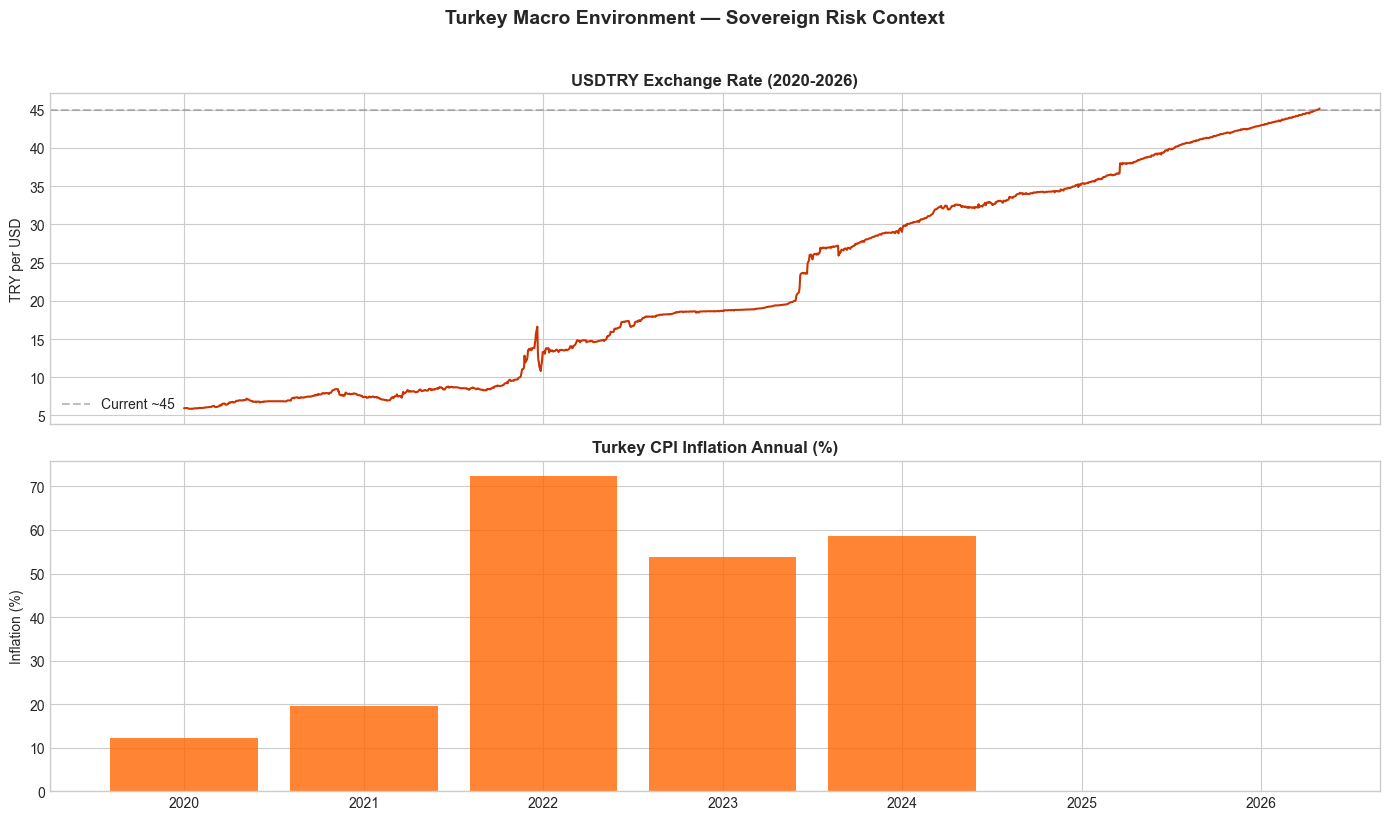

Chart saved.


In [7]:
# ── Visualization 1: USDTRY & Inflation Historical ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# USDTRY daily
axes[0].plot(fx.index, fx["USDTRY"], color="#CC3300", linewidth=1.5)
axes[0].set_title("USDTRY Exchange Rate (2020-2026)", fontweight="bold", fontsize=12)
axes[0].set_ylabel("TRY per USD")
axes[0].axhline(y=45, color="gray", linestyle="--", alpha=0.5, label="Current ~45")
axes[0].legend()

# Inflation annual
macro_clean = macro_combined.dropna(subset=["usdtry_avg"])
axes[1].bar(macro_clean.index, macro_clean["inflation_pct"], 
            color="#FF6600", alpha=0.8, width=300)
axes[1].set_title("Turkey CPI Inflation Annual (%)", fontweight="bold", fontsize=12)
axes[1].set_ylabel("Inflation (%)")
axes[1].axhline(y=0, color="black", linewidth=0.5)

plt.suptitle("Turkey Macro Environment — Sovereign Risk Context", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/sovereign_macro.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

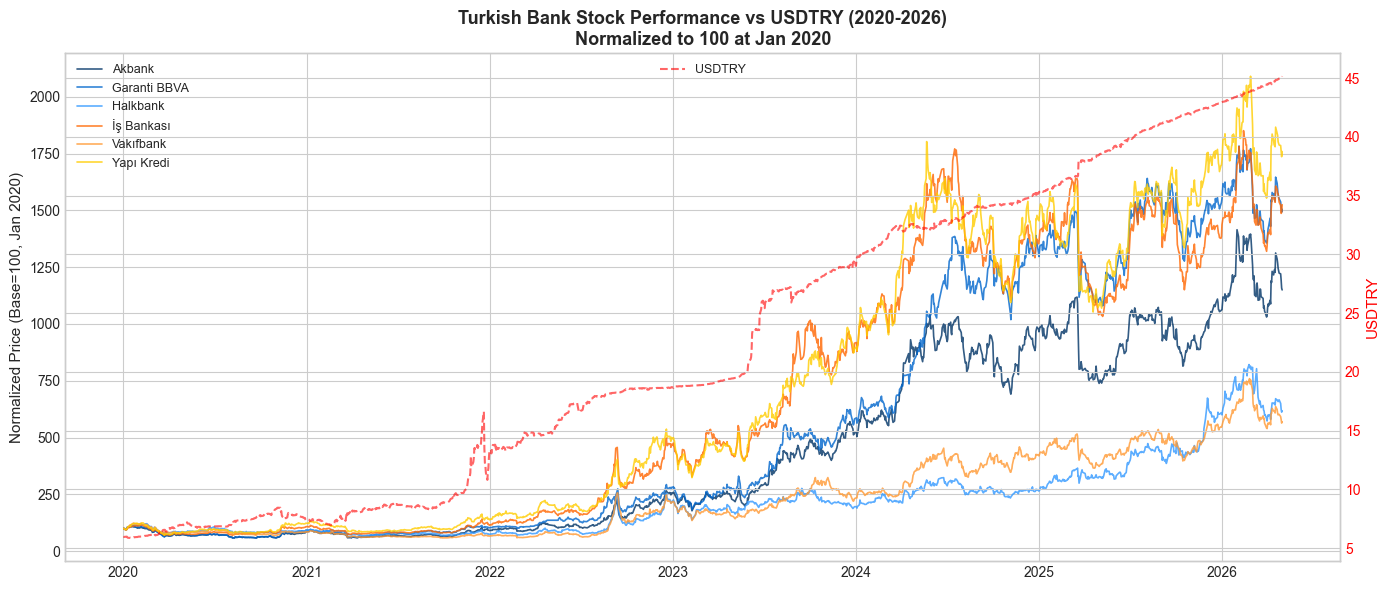

Chart saved.


In [8]:
# ── Visualization 2: Bank Stock Prices vs USDTRY ──────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bank stocks (normalized to 100)
stocks_norm = (stocks / stocks.iloc[0]) * 100
colors = ["#003366", "#0066CC", "#3399FF", "#FF6600", "#FF9933", "#FFCC00"]

for i, bank in enumerate(stocks_norm.columns):
    ax1.plot(stocks_norm.index, stocks_norm[bank], 
             linewidth=1.2, color=colors[i], label=BANKS[bank], alpha=0.8)

ax1.set_ylabel("Normalized Price (Base=100, Jan 2020)", fontsize=11)
ax1.set_xlabel("")
ax1.legend(loc="upper left", fontsize=9)

# USDTRY on secondary axis
ax2 = ax1.twinx()
ax2.plot(fx.index, fx["USDTRY"], color="red", linewidth=1.5, 
         linestyle="--", alpha=0.6, label="USDTRY")
ax2.set_ylabel("USDTRY", fontsize=11, color="red")
ax2.tick_params(axis="y", labelcolor="red")
ax2.legend(loc="upper center", fontsize=9)

plt.title("Turkish Bank Stock Performance vs USDTRY (2020-2026)\nNormalized to 100 at Jan 2020", 
          fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/stocks_vs_fx.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

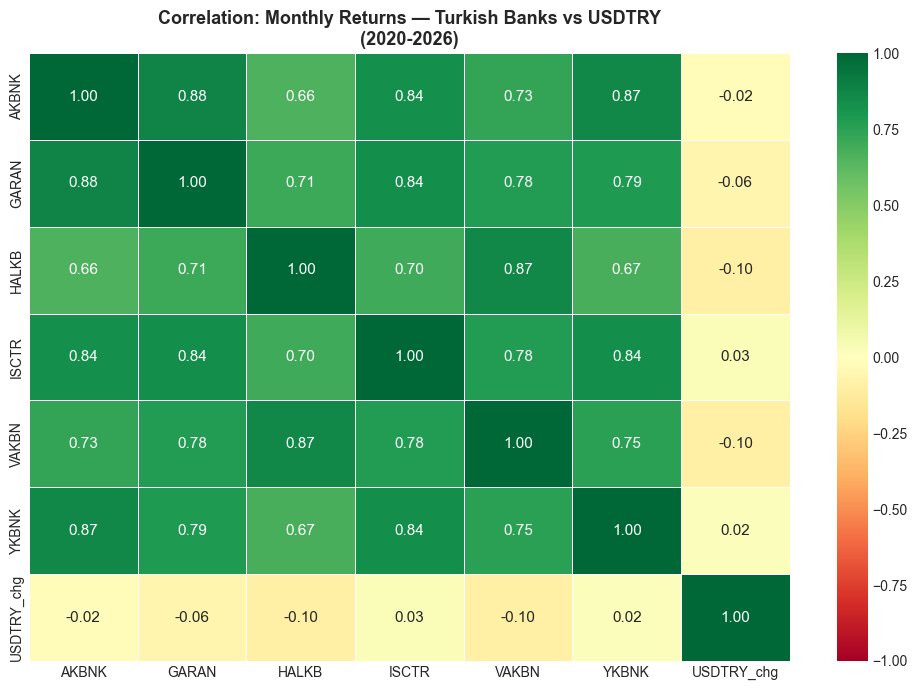

Correlation with USDTRY:
VAKBN   -0.10
HALKB   -0.10
GARAN   -0.06
AKBNK   -0.02
YKBNK    0.02
ISCTR    0.03
Name: USDTRY_chg, dtype: float64


In [9]:
# ── Correlation Analysis: Bank Returns vs USDTRY Changes ──────────────────────
# Monthly returns
stocks_monthly = stocks.resample("ME").last().pct_change().dropna()
fx_monthly = fx["USDTRY"].resample("ME").last().pct_change().dropna()

# Align dates
common_dates = stocks_monthly.index.intersection(fx_monthly.index)
stocks_m = stocks_monthly.loc[common_dates]
fx_m = fx_monthly.loc[common_dates]

# Correlation matrix
corr_data = stocks_m.copy()
corr_data["USDTRY_chg"] = fx_m

corr_matrix = corr_data.corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={"size": 11})

ax.set_title("Correlation: Monthly Returns — Turkish Banks vs USDTRY\n(2020-2026)", 
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Correlation with USDTRY:")
print(corr_data.corr()["USDTRY_chg"].drop("USDTRY_chg").sort_values())

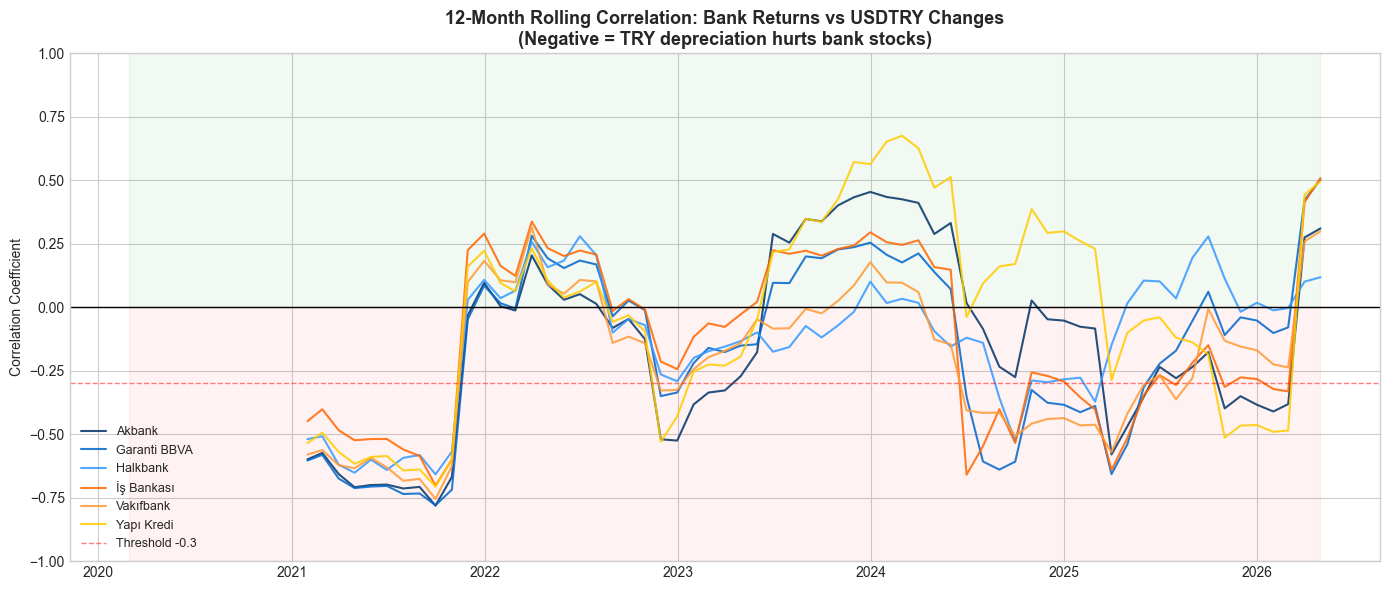

Chart saved.


In [10]:
# ── Rolling Correlation: Banks vs USDTRY ──────────────────────────────────────
# 12-month rolling correlation
rolling_corr = pd.DataFrame()

for bank in stocks_monthly.columns:
    common = stocks_monthly[bank].index.intersection(fx_m.index)
    rolling_corr[BANKS[bank]] = (
        stocks_monthly[bank].loc[common]
        .rolling(12)
        .corr(fx_m.loc[common])
    )

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#003366","#0066CC","#3399FF","#FF6600","#FF9933","#FFCC00"]

for i, col in enumerate(rolling_corr.columns):
    ax.plot(rolling_corr.index, rolling_corr[col],
            linewidth=1.5, color=colors[i], label=col, alpha=0.85)

ax.axhline(y=0, color="black", linewidth=1, linestyle="-")
ax.axhline(y=-0.3, color="red", linewidth=1, linestyle="--", alpha=0.5, label="Threshold -0.3")
ax.fill_between(rolling_corr.index, -1, 0, alpha=0.05, color="red")
ax.fill_between(rolling_corr.index, 0, 1, alpha=0.05, color="green")

ax.set_title("12-Month Rolling Correlation: Bank Returns vs USDTRY Changes\n(Negative = TRY depreciation hurts bank stocks)",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Correlation Coefficient")
ax.legend(loc="lower left", fontsize=9)
ax.set_ylim(-1, 1)

plt.tight_layout()
plt.savefig("../reports/rolling_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [11]:
# ── Key Findings Summary ───────────────────────────────────────────────────────
print("=" * 60)
print("PHASE 2 — SOVEREIGN LINKAGE: KEY FINDINGS")
print("=" * 60)

print("""
1. USDTRY DEPRECIATION (2020-2026)
   - TRY depreciated from ~6 to ~45 per USD (+650%)
   - Controlled devaluation by CBRT since 2022 normalization
   - Current level: ~45 TRY/USD (May 2026)

2. INFLATION DYNAMICS
   - Peak: 72.3% CPI in 2022
   - Gradual normalization: 58.5% in 2024
   - Still elevated — real return erosion continues

3. STOCK-FX CORRELATION
   - Long-run: highly negative (TRY weakness = bank stress)
   - Short-run: near-zero (monthly changes uncorrelated)
   - Rolling analysis: correlation regime shifts with policy cycles

4. INTER-BANK CORRELATION
   - All banks: 0.66-0.88 correlation
   - Systemic risk dominates idiosyncratic risk
   - Private banks (AKBNK, GARAN) show stronger co-movement

5. SOVEREIGN CEILING IMPLICATION
   - Macro environment justifies B sovereign rating
   - Bank standalone profiles stronger than sovereign-implied
   - Rating upside contingent on sustained disinflation + CA improvement
""")

print("Next: Phase 3 — XGBoost Risk Scoring + SHAP Explainability")

PHASE 2 — SOVEREIGN LINKAGE: KEY FINDINGS

1. USDTRY DEPRECIATION (2020-2026)
   - TRY depreciated from ~6 to ~45 per USD (+650%)
   - Controlled devaluation by CBRT since 2022 normalization
   - Current level: ~45 TRY/USD (May 2026)

2. INFLATION DYNAMICS
   - Peak: 72.3% CPI in 2022
   - Gradual normalization: 58.5% in 2024
   - Still elevated — real return erosion continues

3. STOCK-FX CORRELATION
   - Long-run: highly negative (TRY weakness = bank stress)
   - Short-run: near-zero (monthly changes uncorrelated)
   - Rolling analysis: correlation regime shifts with policy cycles

4. INTER-BANK CORRELATION
   - All banks: 0.66-0.88 correlation
   - Systemic risk dominates idiosyncratic risk
   - Private banks (AKBNK, GARAN) show stronger co-movement

5. SOVEREIGN CEILING IMPLICATION
   - Macro environment justifies B sovereign rating
   - Bank standalone profiles stronger than sovereign-implied
   - Rating upside contingent on sustained disinflation + CA improvement

Next: Phase 3 —